## Modularizing Saad’s Statistics Map Game

At this stage, your project is evolving from a collection of exploratory notebook cells into something more structured: an interactive system that guides users through statistical decision-making.

This shift naturally calls for a modular design.

Instead of keeping everything inside a single notebook, you can separate responsibilities into layers:

- **Notebook (or main script):** handles navigation, prompts, and the user experience
- **Modules (.py files):** contain the actual statistical logic, computations, and plots

This separation gives your project clarity and scalability.

---

### Why Modularization Matters

When everything lives in one notebook, a few problems emerge:

- Execution order becomes fragile  
- Code becomes harder to reuse  
- Logic and presentation get mixed together  

By moving core functionality into modules, you gain:

1. **Cleaner structure**  
   Your notebook becomes easier to read and reason about.

2. **Reusability**  
   Functions like repeated validation can be used across multiple parts of your map.

3. **Debugging clarity**  
   You can isolate whether issues come from navigation or computation.

---

### Conceptual Architecture

Think of your system like this:

- **Notebook = Control Layer (UI / Map)**
- **Modules = Engine Layer (Computation / Logic)**

The notebook asks:
> “What should we do next?”

The modules answer:
> “Here is the result.”

---

### Example Project Structure


In [8]:
""" 
saads_statistics_map/
│
├── main.ipynb # interactive map / UI
├── menus.py # navigation logic
├── validation.py # repeated validation, CV
├── regression.py # linear, polynomial models
├── diagnostics.py # residuals, leverage, etc.
├── data_utils.py # loading & preprocessing
"""

print()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def polynomial_repeated_validation(x=None, y=None, n_splits=10, max_degree=10):

    # fallback simulated data (replace later)
    if x is None or y is None:
        np.random.seed(42)
        n = 70
        x = np.random.uniform(-4, 4, n)
        y = 6 + 2.5*x - 2.8*x**2 + np.random.normal(0, 6, n)

    degrees = range(1, max_degree + 1)
    all_mse = []

    n = len(x)

    for i in range(n_splits):
        idx = np.random.permutation(n)
        split = n // 2

        train_idx = idx[:split]
        val_idx = idx[split:]

        mse_row = []

        for d in degrees:
            X_train = np.column_stack([x[train_idx]**k for k in range(d + 1)])
            X_val = np.column_stack([x[val_idx]**k for k in range(d + 1)])

            beta = np.linalg.pinv(X_train) @ y[train_idx]
            y_pred = X_val @ beta

            mse = np.mean((y[val_idx] - y_pred)**2)
            mse_row.append(mse)

        all_mse.append(mse_row)

    all_mse = np.array(all_mse)

    mean_mse = all_mse.mean(axis=0)
    std_mse = all_mse.std(axis=0)

    print("\nDegree | Mean MSE | Std MSE")
    print("----------------------------")
    for d in degrees:
        print(f"{d:>6} | {mean_mse[d-1]:>8.2f} | {std_mse[d-1]:>7.2f}")

    plt.figure(figsize=(8,5))

    for row in all_mse:
        plt.plot(degrees, row, alpha=0.5)

    plt.plot(degrees, mean_mse, linewidth=2)

    upper = np.percentile(all_mse, 90)
    plt.ylim(0, upper)

    plt.xlabel("Polynomial Degree")
    plt.ylabel("Validation MSE")
    plt.title("Validation MSE Across Splits")
    plt.xticks(list(degrees))
    plt.show()

In [2]:
def run_game():

    print("\nWelcome to Saad's Statistics Map Game\n")

    main_menu = {
        "1": "Define the problem",
        "2": "Understand the data",
        "3": "Visualize the data",
        "4": "Modelling the problem",
        "5": "Evaluate the model",
        "6": "Make decisions"
    }

    for k, v in main_menu.items():
        print(f"{k}. {v}")

    choice = input("\nChoose option: ").strip()

    if choice == "4":
        modelling_menu()

In [3]:
def modelling_menu():

    print("\n--- Modelling ---\n")

    model_menu = {
        "1": "Linear models",
        "2": "Tree-based models",
        "3": "Other methods"
    }

    for k, v in model_menu.items():
        print(f"{k}. {v}")

    choice = input("\nChoose option: ").strip()

    if choice == "1":
        linear_models_menu()

In [4]:
def linear_models_menu():

    print("\n--- Linear Models ---\n")

    linear_menu = {
        "1": "Simple linear regression",
        "2": "Multiple linear regression",
        "3": "Polynomial regression"
    }

    for k, v in linear_menu.items():
        print(f"{k}. {v}")

    choice = input("\nChoose option: ").strip()

    if choice == "3":
        polynomial_menu()

In [5]:
def polynomial_menu():

    print("\n--- Polynomial Regression ---\n")

    poly_menu = {
        "1": "Fit polynomial model",
        "2": "Choose degree by repeated validation",
        "3": "Compare training vs validation error"
    }

    for k, v in poly_menu.items():
        print(f"{k}. {v}")

    choice = input("\nChoose option: ").strip()

    if choice == "2":
        print("\nRunning repeated validation...\n")
        polynomial_repeated_validation()


Welcome to Saad's Statistics Map Game

1. Define the problem
2. Understand the data
3. Visualize the data
4. Modelling the problem
5. Evaluate the model
6. Make decisions

--- Modelling ---

1. Linear models
2. Tree-based models
3. Other methods

--- Linear Models ---

1. Simple linear regression
2. Multiple linear regression
3. Polynomial regression

--- Polynomial Regression ---

1. Fit polynomial model
2. Choose degree by repeated validation
3. Compare training vs validation error

Running repeated validation...


Degree | Mean MSE | Std MSE
----------------------------
     1 |   268.46 |   63.57
     2 |    34.40 |    6.08
     3 |    36.23 |    5.85
     4 |    32.65 |    5.48
     5 |    33.93 |    5.12
     6 |    36.86 |    3.90
     7 |    41.96 |    8.91
     8 |    50.69 |   37.19
     9 |    50.97 |   30.23
    10 |   157.85 |  319.80


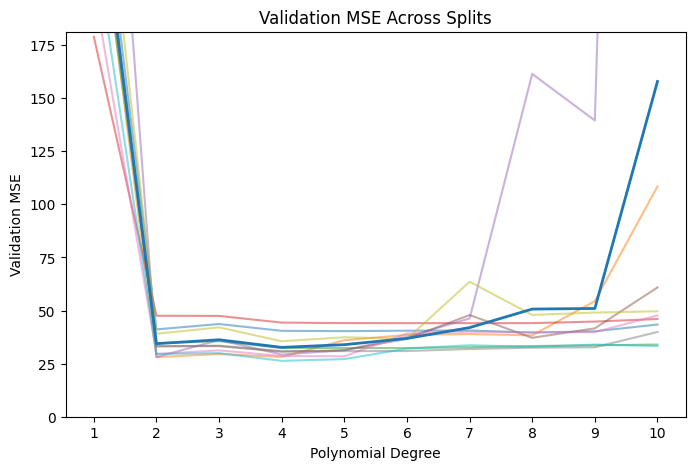

In [6]:
run_game()